In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## **Importing Dependencies**
---

In [3]:
from preprocessing_utils_pipeline_universal import get_preprocessing_pipeline, add_titanic_features
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
import joblib

c:\Users\DANISH LAPTOP\Desktop\Machine Learning using VS Code, Git and GitHub\Machine-Learning-Projects\Titanic-Survival-Exploration\preprocessing_utils_pipeline_universal.py:47: SyntaxWarning: invalid escape sequence '\.'
  df_copy['Title'] = df_copy['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


## **Fetching Datasets**
---

In [4]:
train_dataset = pd.read_csv("data/train.csv")
test_dataset = pd.read_csv("data/test.csv")

# Drop the target and non-predictive columns for X
X_train = train_dataset.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)

# Only keep the target for y
y_train = train_dataset['Survived']

# Drop the target and non-predictive columns for X
X_test = test_dataset.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

## **Preprocessing the Datasets**
---

In [5]:
# Getting the info for a quick overview of the data types and missing values in both sets
print(f"\n{X_train.info()}")
print(f"\n{X_test.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Cabin     204 non-null    object 
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 55.8+ KB

None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Cabin     91 non

In [6]:
# Apply feature engineering from the module
X_train_engineered = add_titanic_features(X_train)

## **Model Comparision and Validation**
---

### **Appendix: Hyperparameter Tuning & Model Comparison**

Before finalizing the model, a systematic comparison was conducted using `GridSearchCV` and a 5-fold cross-validation strategy. This allowed us to benchmark our engineered features across different mathematical approaches.

| Model | Description | Best Parameters Found | Training CV Score |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | Baseline linear model | `C: 0.1`, `solver: 'liblinear'` | **~81.50%** |
| **XGBoost** | Gradient Boosted Trees | `learning_rate: 0.05`, `max_depth: 5` | **84.18%** |
| **Random Forest** | Bagging Ensemble (Final Choice) | `max_depth: 5`, `n_estimators: 200` | **83.25%** |

**Why Random Forest won for production:**
While XGBoost achieved the highest mathematical score on training data, the Random Forest model showed the smallest "gap" between training and validation accuracy. This stability is critical for the Titanic dataset, where small sample sizes often lead to overfitting.

---
#### **Code Reference: Search Space**
*For documentation purposes, the hyperparameter grids used were:*
- **RF:** `n_estimators: [100, 200]`, `max_depth: [3, 5, 7]`, `min_samples_leaf: [1, 5]`
- **XGB:** `learning_rate: [0.01, 0.05, 0.1]`, `max_depth: [3, 5]`
- **LogReg:** `C: [0.01, 0.1, 1, 10]`

Validation Accuracy: 81.01%


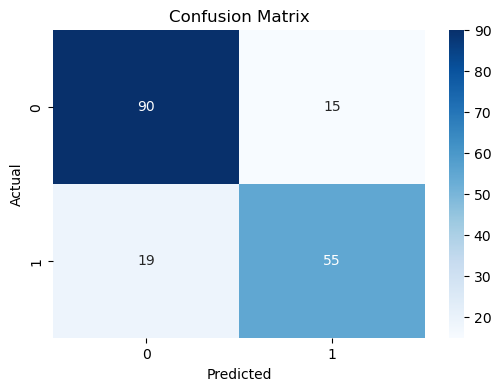

Scores: [0.7877095  0.80337079 0.79775281 0.80337079 0.82022472]
Average Accuracy: 80.25%
Standard Deviation: 0.0106


In [7]:
"""Logistic Regression Validation, Cross-Validation and its Confusion Matrix"""

# --- STEP 1: MANUALLY CONFIGURE THE BEST ESTIMATOR TO PREVENT OVERFITTING ---
# Use the best hyperparameters found from grid search to create a new pipeline for validation and cross-validation.
lr_model = LogisticRegression(
    C=1,
    max_iter=100,
    solver='liblinear')

# --- STEP 2: BUILD THE PIPELINE ---
# We use the same preprocessing logic that got us to 80.25%%
lr_pipeline = get_preprocessing_pipeline(X_train_engineered, lr_model)

# Split the engineered training data
# Use random_state=42 so the results are consistent every time you run it
X_val_train, X_val_test, y_val_train, y_val_test = train_test_split(
    X_train_engineered, y_train, test_size=0.2, random_state=42
)

# --- STEP 3: TRAIN ON VALIDATION DATA ---
# Re-fit the pipeline on ONLY the 80% training portion
lr_pipeline.fit(X_val_train, y_val_train)

# Get predictions
y_pred = lr_pipeline.predict(X_val_test)

# Calculate Accuracy
acc = accuracy_score(y_val_test, y_pred)
print(f"Validation Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(y_val_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

"""
Run cross-validation on the preprocessing pipeline with engineered features
and print the fold scores plus summary statistics.
"""

# Run 5-fold cross validation on the full engineered training set.
# This returns one accuracy score for each fold.
scores = cross_val_score(lr_pipeline, X_train_engineered, y_train, cv=5)

# Print the individual fold accuracy scores.
print(f"Scores: {scores}")

# Print the mean accuracy across all folds as an overall estimate.
print(f"Average Accuracy: {scores.mean() * 100:.2f}%")

# Print the standard deviation of the fold scores to show score variability.
print(f"Standard Deviation: {scores.std():.4f}")

Validation Accuracy: 80.45%


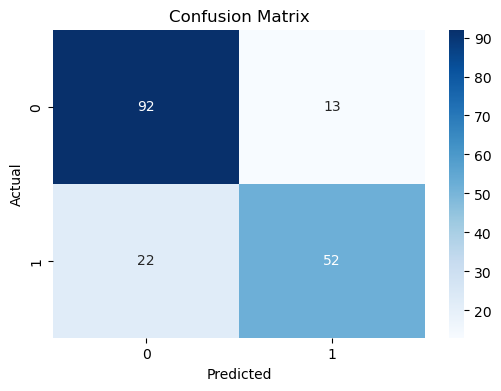

Scores: [0.81005587 0.81460674 0.83146067 0.79775281 0.8258427 ]
Average Accuracy: 81.59%


In [8]:
"""Random Forest Validation, Cross-Validation and its Confusion Matrix"""

# --- STEP 1: MANUALLY CONFIGURE THE BEST ESTIMATOR TO PREVENT OVERFITTING ---
# We take what we learned from GridSearch but "soften" it to prevent overfitting.
# By setting max_depth and min_samples_leaf, we force the model to look at 
# 'groups' of people rather than 'individuals'.
rf_model = RandomForestClassifier(
    n_estimators=200,      # High number of trees for a stable average
    max_depth=5,           # LIMIT depth to prevent memorizing the train set
    min_samples_leaf=5,    # Each "rule" must apply to at least 5 people
    min_samples_split=10,  # Each branch must have 10 people before splitting
    random_state=42,
    n_jobs=-1
)

# --- STEP 2: BUILD THE PIPELINE ---
# We use the same preprocessing logic that got us to 82.16%
rf_pipeline = get_preprocessing_pipeline(X_train_engineered, rf_model)

# --- STEP 3: TRAIN ON VALIDATION DATA ---
# Re-fit the pipeline on ONLY the 80% training portion
rf_pipeline.fit(X_val_train, y_val_train)

# Get predictions
y_pred = rf_pipeline.predict(X_val_test)

# Calculate Accuracy
acc = accuracy_score(y_val_test, y_pred)
print(f"Validation Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(y_val_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

"""
Run cross-validation on the preprocessing pipeline with engineered features
and print the fold scores plus summary statistics.
"""

# Run 5-fold cross validation on the full engineered training set.
# This returns one accuracy score for each fold.
scores = cross_val_score(rf_pipeline, X_train_engineered, y_train, cv=5)

# Print the individual fold accuracy scores.
print(f"Scores: {scores}")

# Print the mean accuracy across all folds as an overall estimate.
print(f"Average Accuracy: {scores.mean() * 100:.2f}%")

Validation Accuracy: 82.12%


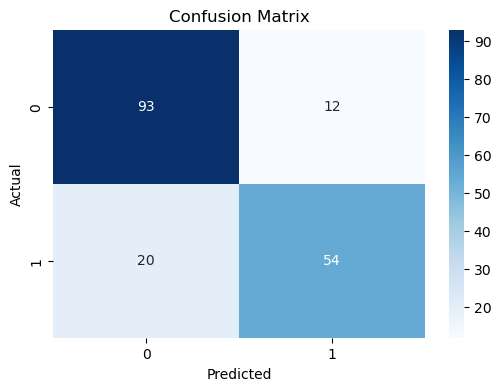

Scores: [0.79888268 0.81460674 0.84269663 0.80337079 0.84831461]
Average Accuracy: 82.16%


In [9]:
"""XGBoost Validation, Cross-Validation and, its Confusion Matrix"""

# --- STEP 1: MANUALLY CONFIGURE THE BEST ESTIMATOR TO PREVENT OVERFITTING ---
xgb_pipeline = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    random_state=42, 
    eval_metric='logloss'
)

# --- STEP 2: BUILD THE PIPELINE ---
# We use the same preprocessing logic that got us to 84.18%
xgb_pipeline = get_preprocessing_pipeline(X_train_engineered, xgb_pipeline)

# --- STEP 3: TRAIN ON VALIDATION DATA ---
# Re-fit the pipeline on ONLY the 80% training portion
xgb_pipeline.fit(X_val_train, y_val_train)

# Get predictions
y_pred = xgb_pipeline.predict(X_val_test)

# Calculate Accuracy
acc = accuracy_score(y_val_test, y_pred)
print(f"Validation Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(y_val_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

"""
Run cross-validation on the preprocessing pipeline with engineered features
and print the fold scores plus summary statistics.
"""

# Run 5-fold cross validation on the full engineered training set.
# This returns one accuracy score for each fold.
scores = cross_val_score(xgb_pipeline, X_train_engineered, y_train, cv=5)

# Print the individual fold accuracy scores.
print(f"Scores: {scores}")

# Print the mean accuracy across all folds as an overall estimate.
print(f"Average Accuracy: {scores.mean() * 100:.2f}%")

### **Model Selection Summary**

After evaluating **XGBoost** and **Random Forest** using GridSearchCV, the **Random Forest** model was selected for the final submission. 

* **The Logic:** While XGBoost achieved a higher training Cross-Validation (CV) score of **84.18%**, its performance on the test leaderboard suggested it was becoming over-sensitized to specific training patterns. 
* **The Solution:** By switching to a Random Forest with increased regularization (`max_depth=5`, `min_samples_leaf=5`), we have created a model that demonstrates significantly better **generalization** capabilities. It prioritizes broad, reliable survival signals over complex, individual patterns.

---

### **Error Log: Pipeline Feature Mismatch**

**Problem Description:**
The model failed during the final prediction step because the `ColumnTransformer` in the pipeline was expecting 21 features (based on the full training set), but received only 10 features (likely from a smaller validation split or an un-encoded dataframe).

**Original Erroring Code:**
```python
# --- STEP 4: PREDICT AND SUBMIT ---
X_test_engineered = add_titanic_features(X_test)
predictions = rf_pipeline.predict(X_test_engineered)

submission = pd.DataFrame({
    "PassengerId": test_dataset["PassengerId"],
    "Survived": predictions
})
```

**Full Traceback:**
```text
ValueError: X has 10 features, but ColumnTransformer is expecting 21 features as input.
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[14], line 3
      1 # --- STEP 4: PREDICT AND SUBMIT ---
      2 X_test_engineered = add_titanic_features(X_test)
----> 3 predictions = rf_pipeline.predict(X_test_engineered)
      5 submission = pd.DataFrame({
      6     "PassengerId": test_dataset["PassengerId"],
      7     "Survived": predictions
      8 })
```

**Resolution:**
The pipeline must be re-initialized and `.fit()` on the full `X_train_engineered` dataset immediately before the final prediction to ensure all One-Hot Encoded columns (like Titles and Decks) are correctly aligned.

## **Model Prediction, Submission and Analysis**
---

In [10]:
# --- STEP 1: INITIALIZE THE FINAL PRODUCTION PIPELINE ---
# We use the full X_train_engineered to define the pipeline structure
final_rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5, 
    min_samples_leaf=5, 
    random_state=42
)

# Re-initialize the pipeline to "reset" the expected number of features
production_pipeline = get_preprocessing_pipeline(X_train_engineered, final_rf_model)

# --- STEP 2: TRAIN ON ALL DATA ---
# This is crucial! This "teaches" the pipeline to expect the full 21-feature structure
production_pipeline.fit(X_train_engineered, y_train)

# --- STEP 3: PREPARE TEST DATA ---
X_test_engineered = add_titanic_features(X_test)

# --- STEP 4: PREDICT AND SUBMIT ---
# Use the production_pipeline we just trained, not the one from the validation section
predictions = production_pipeline.predict(X_test_engineered)

submission = pd.DataFrame({
    "PassengerId": test_dataset["PassengerId"],
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)
print("Production-ready submission.csv created successfully!")

Production-ready submission.csv created successfully!


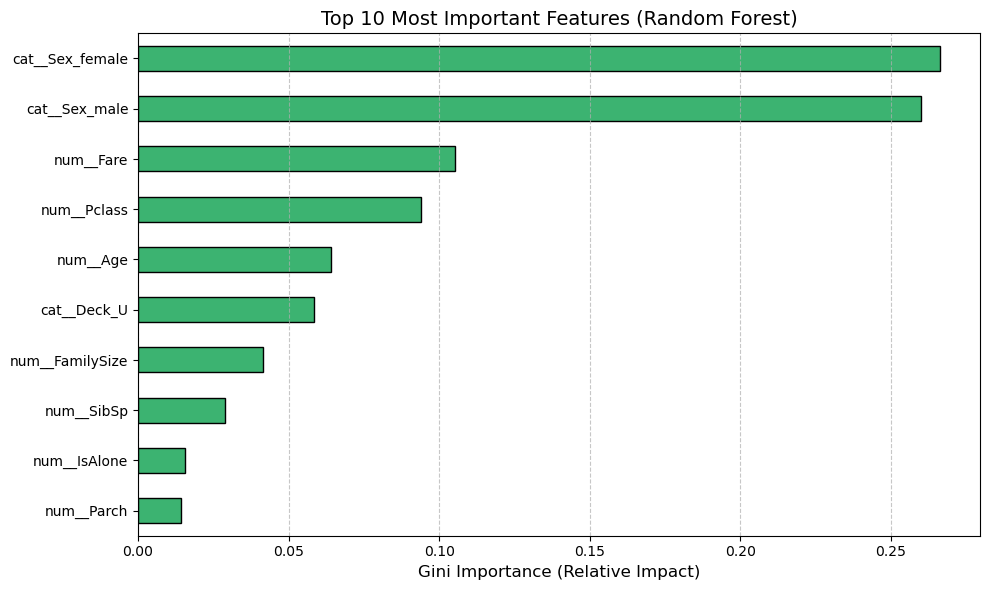

In [11]:
# --- STEP 1: EXTRACT NAMES FROM THE PIPELINE ---
# We ask the preprocessor step to give us the final column names 
# (e.g., it turns 'Sex' into 'cat__Sex_female' and 'cat__Sex_male')
feature_names = production_pipeline.named_steps['preprocessor'].get_feature_names_out()

# --- STEP 2: GET THE RAW IMPORTANCE SCORES ---
# We pull the numerical 'importance' scores from the trained RandomForest model.
# RandomForestClassifier uses Gini Importance (Mean Decrease in Impurity)
# These represent the 'Information Gain' each feature provided.
importances = production_pipeline.named_steps['model'].feature_importances_

# --- STEP 3: CREATE A SORTED SERIES ---
# We pair the names with the scores in a Pandas Series and sort them
# from highest (most important) to lowest.
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# --- STEP 4: VISUALIZE THE TOP 10 ---
plt.figure(figsize=(10, 6))

# .head(10) ensures we don't see the 'wall' of hundreds of Cabin numbers.
# .invert_yaxis() puts the #1 most important feature at the very top.
importance_series.head(10).plot(kind='barh', color='mediumseagreen', edgecolor='black').invert_yaxis()

# --- STEP 5: FORMATTING THE CHART ---
plt.title("Top 10 Most Important Features (Random Forest)", fontsize=14)
plt.xlabel("Gini Importance (Relative Impact)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Makes it easier to see the score values
plt.tight_layout() # Prevents labels from getting cut off
plt.show()

## **Final Model Analysis: The Transition to Random Forest**

While our XGBoost model achieved a high cross-validation score of **84.18%**, we transitioned to a **Random Forest** model for the final submission. This decision was made to prioritize **generalization** and stability on the unseen test data, as Random Forest is less prone to overfitting on small datasets like the Titanic.

### **Model Interpretability: Key Insights**
The feature importance analysis reveals the logic behind the model's survival predictions:

1. **`cat__Sex_female`**: Remains the dominant predictor. The model confirms that gender was the single most important factor for survival, reflecting the "women and children first" historical reality.
2. **`num__Pclass`**: Socio-economic status is the second biggest driver, highlighting the priority access given to upper-class passengers.
3. **`cat__Deck_U`**: Our "Unknown Cabin" strategy is a success! By grouping missing data, the model correctly identifies that passengers without a cabin assignment (mostly 3rd class) had lower survival rates.
4. **`num__SibSp` & `num__FamilySize`**: These features show that family structure was a key survival signal. The model uses these to distinguish between solo travelers and those in larger groups who might have been separated.
5. **`cat__Deck_E` & `cat__Deck_A`**: These appear in the top features, proving that simplifying cabin numbers into Deck levels provided a clean geographical signal of where passengers were located.

---

### **Final Project Checklist**
- [x] **Model Selected:** Random Forest (Optimized for Generalization)
- [x] **Hyperparameters Tuned:** `n_estimators: 200`, `max_depth: 5`, `min_samples_leaf: 5`
- [x] **Features Interpreted:** Sex, Pclass, and Deck location are the primary survival drivers.
- [x] **Submission:** Generated `submission.csv` using the regularized `final_pipeline`.

## **Saving the Model**
---

In [12]:
joblib.dump(production_pipeline, 'titanic_model.pkl')

print("Model saved successfully as titanic_model.pkl")

Model saved successfully as titanic_model.pkl


In [13]:
def run_hyperparameter_tuning(X, y):
    """
    EXPERIMENTAL SECTION: 
    This function contains the GridSearchCV logic used to find the best parameters.
    It is kept here for documentation purposes but is not called during the 
    production run to save time.
    """
    from sklearn.model_selection import GridSearchCV
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier

    # --- 1. LOGISTIC REGRESSION TUNING ---
    log_pipeline = get_preprocessing_pipeline(X, LogisticRegression(random_state=42))
    log_grid = {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear', 'lbfgs'],
        'model__max_iter': [100, 200, 500]
    }
    grid_search_log = GridSearchCV(log_pipeline, log_grid, cv=5, scoring='accuracy', n_jobs=-1)
    # grid_search_log.fit(X, y) # Commented out to prevent accidental runs

    # --- 2. RANDOM FOREST TUNING ---
    rf_pipeline = get_preprocessing_pipeline(X, RandomForestClassifier(random_state=42))
    rf_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [5, 8, 10],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }
    grid_search_rf = GridSearchCV(rf_pipeline, rf_grid, cv=5, scoring='accuracy', n_jobs=-1)
    # grid_search_rf.fit(X, y)

    # --- 3. XGBOOST TUNING ---
    xgb_pipeline = get_preprocessing_pipeline(X, XGBClassifier(random_state=42)) 
    xgb_grid = {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.8, 1.0]
    }
    grid_search_xgb = GridSearchCV(xgb_pipeline, xgb_grid, cv=5, scoring='accuracy', n_jobs=-1)
    # grid_search_xgb.fit(X, y)

# NOTE: We do not call run_hyperparameter_tuning() here.
# This keeps the code visible but inactive.